# 02. Exploratory Data Analysis & Spatial Clustering

This notebook conducts exploratory analysis, spatial feature engineering, and unsupervised market segmentation on the clean Poznań residential housing dataset ($N = 38,154$).

---

### Key Analytical Deliverables
1. **Data Completeness & Distributions:** Audit missingness and examine unit price distributions ($\text{PLN/m}^2$ vs. $\log(1 + p)$).
2. **Temporal Dynamics:** Analyze median transaction price trends and price dispersion from 2013 to 2025.
3. **Spatial Gradient:** Evaluate the monocentric price-distance gradient from the city center (`odl_do_centrum`).
4. **Linear & Non-Linear Dependency Analysis:** Contrast Pearson correlation with Mutual Information and examine time series autocorrelation (ACF).
5. **Three Unsupervised Learning Engines:**
   - **Spatial Density Clustering:** HDBSCAN on projected coordinates (`wsp_x`, `wsp_y`) to extract dense urban submarkets.
   - **Hedonic Property Segmentation:** K-Means clustering on physical apartment attributes (`powierzchnia_final`, `metry_na_izbe`, `odl_do_centrum`, `nr_kondygnacji`).
   - **Macroeconomic Market Regimes:** K-Means clustering on temporal and macroeconomic indicators (`rok_miesiac_float`, `wibor_3m`, `srednie_wynagrodzenie`).


## 1. Environment & Data Loading
Initialize visualization parameters, autoreload extensions, and load the preprocessed residential market dataset.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import pandas as pd

project_root = Path.cwd().resolve()
if not (project_root / "pyproject.toml").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.reporting import summarize_dataset
from src.viz import (
    set_plot_style,
    plot_missingness,
    plot_target_distributions,
    plot_price_over_time,
    plot_price_vs_distance,
    plot_corr_heatmap,
)

root = project_root
df = pd.read_csv(root / "data" / "processed" / "housing_residential_market.csv")
df["log_price"] = np.log1p(df["cena_za_m2"])
set_plot_style()
summarize_dataset(df)

,rows,columns,missing_pct
0,38154,33,12.165054


## 2. Missingness & Completeness Audit
Audit missing data proportions across physical, cadastral, and spatial attributes to confirm data readiness.


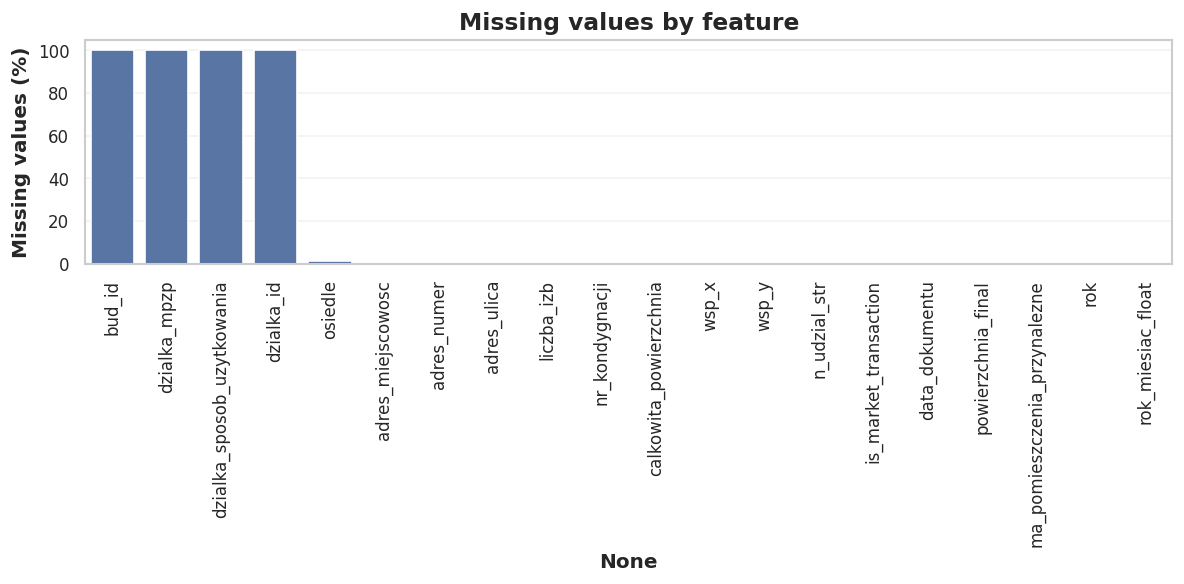

In [2]:
plot_missingness(df, top_n=20)

## 3. Target Variable Distribution & Variance Stabilization
Evaluate the distribution of transaction prices per square meter ($\text{PLN/m}^2$) alongside its log-transformed representation $\log(1 + p)$. Log-transformation mitigates heavy right skew and homoscedasticizes error variance for regression modeling.


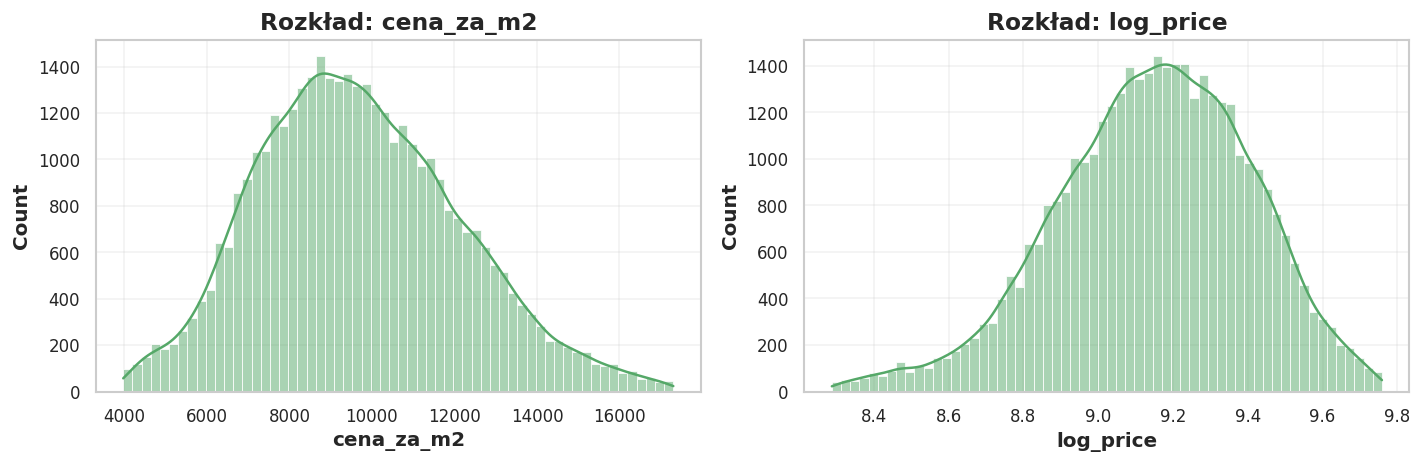

In [3]:
plot_target_distributions(df, ["cena_za_m2", "log_price"])

## 4. Long-Term Price Dynamics (2013–2025)
Track annual median price trajectories and interquartile dispersion, illustrating the acceleration of nominal apartment prices over the 12-year window.


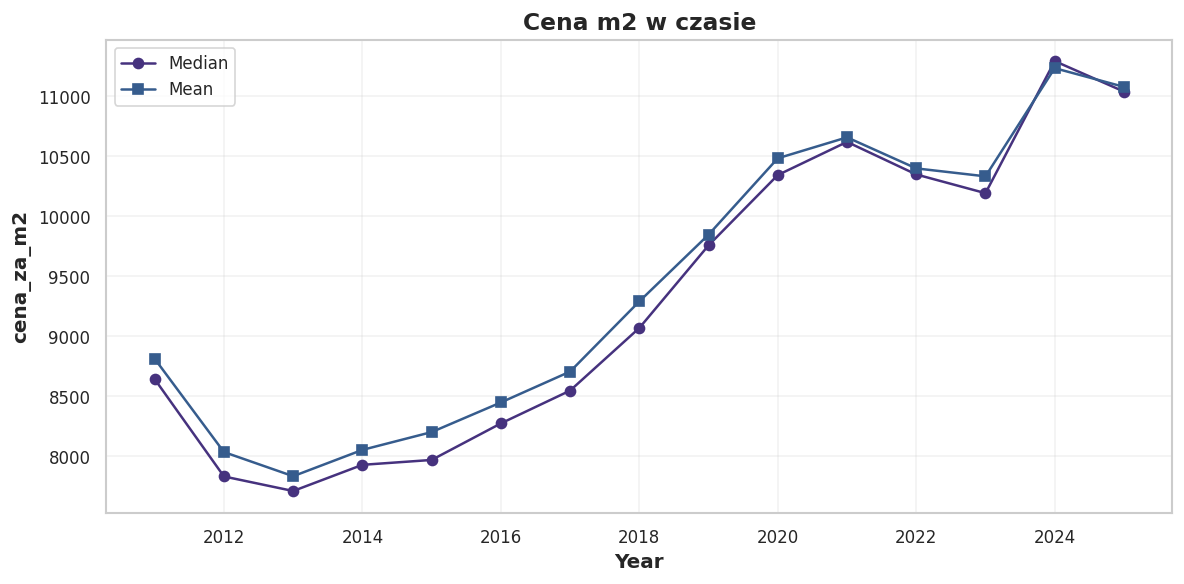

In [4]:
plot_price_over_time(df, "rok", "cena_za_m2")

## 5. Monocentric Spatial Gradient: Distance to Center
Analyze transaction price per square meter against radial distance from the Poznań Old Market (`odl_do_centrum`). The downward sloping gradient reflects classic urban economic bid-rent theory.


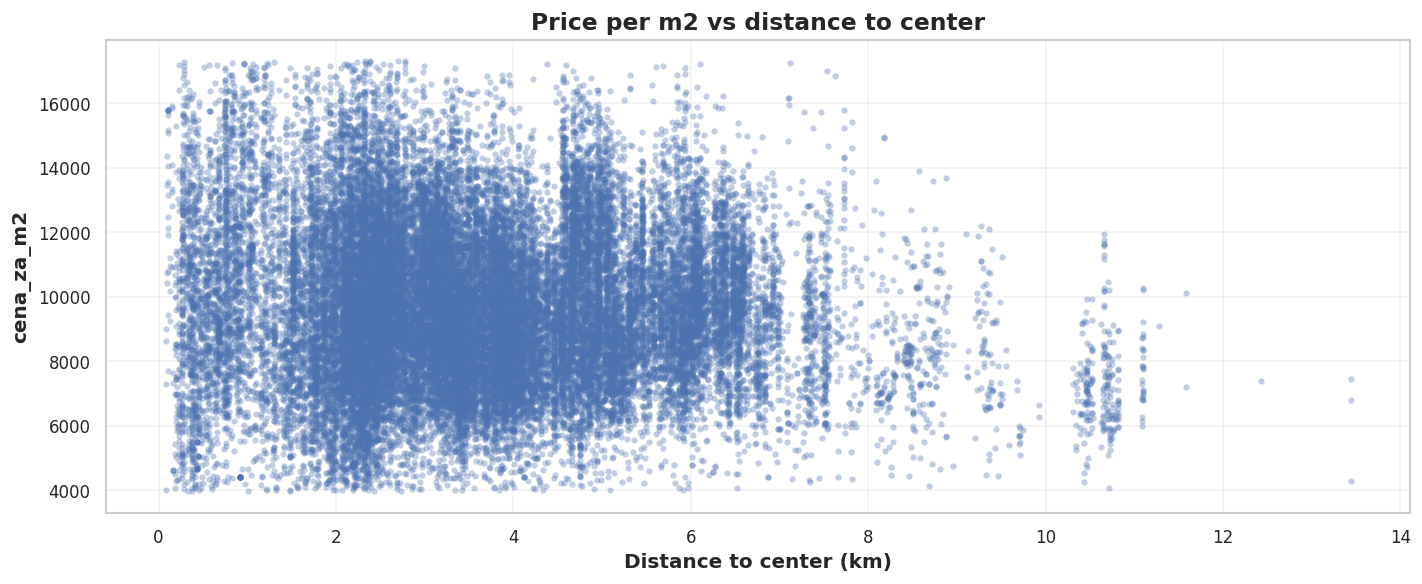

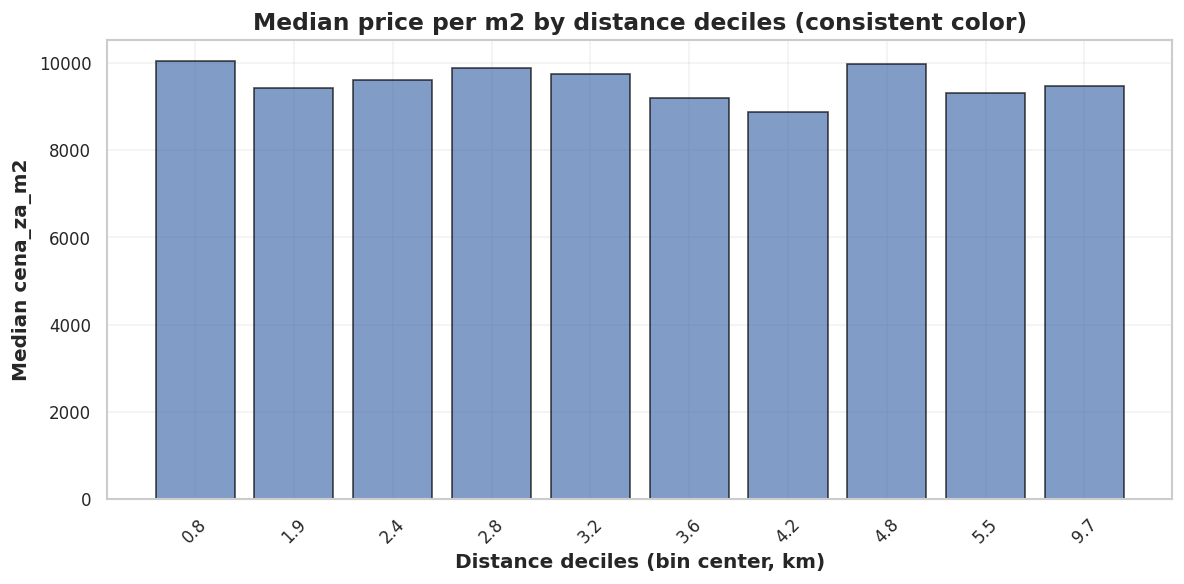

In [5]:
plot_price_vs_distance(df, "odl_do_centrum", "cena_za_m2")

## 6. Linear Feature Correlation Matrix
Compute Pearson correlation coefficients across structural property characteristics, spatial location, and macroeconomic indicators.


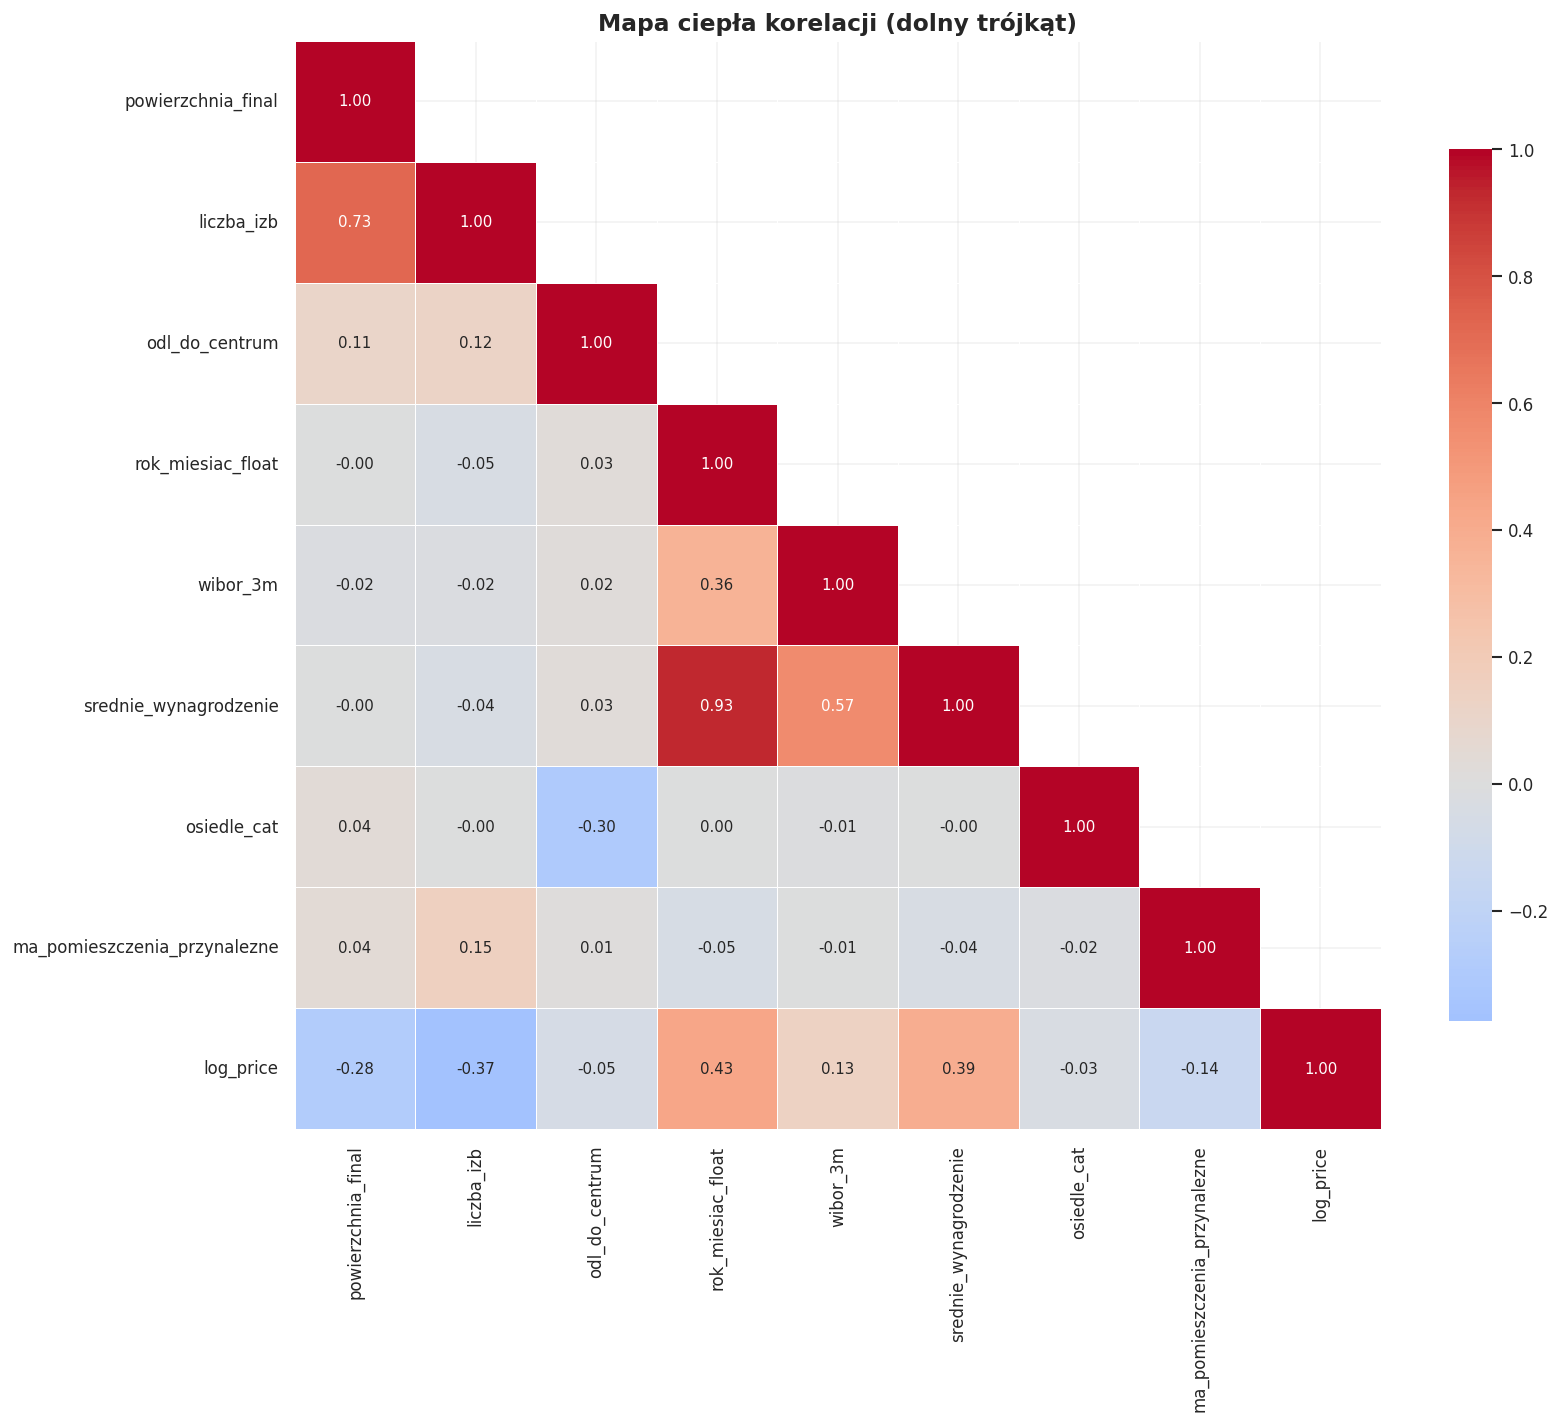

In [6]:
corr_cols = [c for c in [
    "powierzchnia_final", "liczba_izb", "odl_do_centrum", "rok_miesiac_float",
    "wibor_3m", "srednie_wynagrodzenie", "osiedle_cat", "ma_pomieszczenia_przynalezne",
    "log_price",
] if c in df.columns]
plot_corr_heatmap(df[corr_cols])

## 7. Autocorrelation & Non-Linear Dependencies (Mutual Information)

While Pearson correlation captures linear relationships, real estate price dynamics exhibit strong non-linear interactions and temporal persistence. We compute:
1. **Autocorrelation Function (ACF):** Measuring month-to-month price autocorrelation.
2. **Mutual Information Regression:** Quantifying non-linear predictive capacity across physical and macroeconomic variables.



--- Generowanie wykresu autokorelacji (ACF) ---


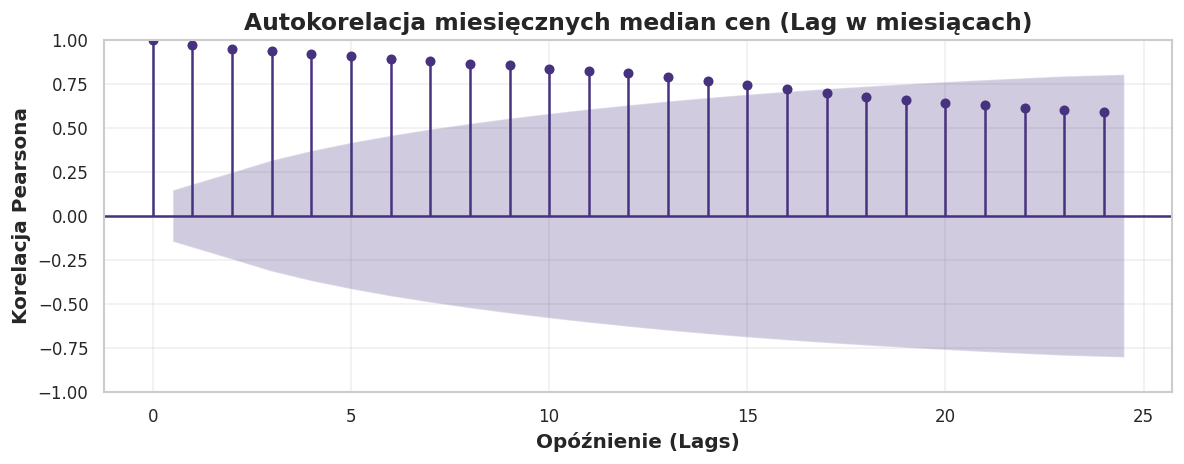

In [7]:

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

print("\n--- Generowanie wykresu autokorelacji (ACF) ---")
monthly_median = df.groupby('rok_miesiac_float')['cena_za_m2'].median()

plots_dir = project_root / 'plots'
plots_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 4))
ax = plt.gca()
plot_acf(
    monthly_median.dropna(),
    lags=24,
    ax=ax,
    title='Autokorelacja miesięcznych median cen (Lag w miesiącach)',
)
plt.xlabel('Opóźnienie (Lags)')
plt.ylabel('Korelacja Pearsona')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(plots_dir / 'acf.png', dpi=150, bbox_inches='tight')
plt.show()


In [8]:
from sklearn.feature_selection import mutual_info_regression

feature_cols = [
    "powierzchnia_final", "liczba_izb", "odl_do_centrum", "rok_miesiac_float",
    "wibor_3m", "srednie_wynagrodzenie", "osiedle_cat", "ma_pomieszczenia_przynalezne",
]
available = [c for c in feature_cols if c in df.columns]
mi_df = df[["log_price", *available]].dropna().copy()
mi_rows = []
for col in available:
    if pd.api.types.is_numeric_dtype(mi_df[col]):
        mi = mutual_info_regression(mi_df[[col]], mi_df["log_price"], random_state=42)[0]
        mi_rows.append({"feature": col, "mutual_information": float(mi)})

pd.DataFrame(mi_rows).sort_values("mutual_information", ascending=False).head(10)

,feature,mutual_information
5,srednie_wynagrodzenie,0.166239
3,rok_miesiac_float,0.164469
4,wibor_3m,0.146116
0,powierzchnia_final,0.118067
6,osiedle_cat,0.109511
2,odl_do_centrum,0.102333
1,liczba_izb,0.097534
7,ma_pomieszczenia_przynalezne,0.018621


## 8. Spatial Density, Hedonic Clustering, and Market Segmentation

To uncover latent submarket structure, non-linear spatial dependencies, and temporal regimes, we employ three unsupervised learning pipelines:
1. **Spatial Density & HDBSCAN Clustering:** Density-based clustering on projected coordinates identifies contiguous urban submarkets while filtering geographical noise/outliers.
2. **Hedonic Property Segmentation (K-Means):** Unsupervised grouping on physical attributes (`powierzchnia_final`, `metry_na_izbe`, `odl_do_centrum`, `nr_kondygnacji`) segmenting properties into distinct architectural typologies.
3. **Macroeconomic Market Regimes (K-Means):** Clustering across the temporal and monetary dimension (`rok_miesiac_float`, `wibor_3m`, `srednie_wynagrodzenie`) to quantify discrete macroeconomic eras (credit boom, pandemic stimulus, inflation shock).


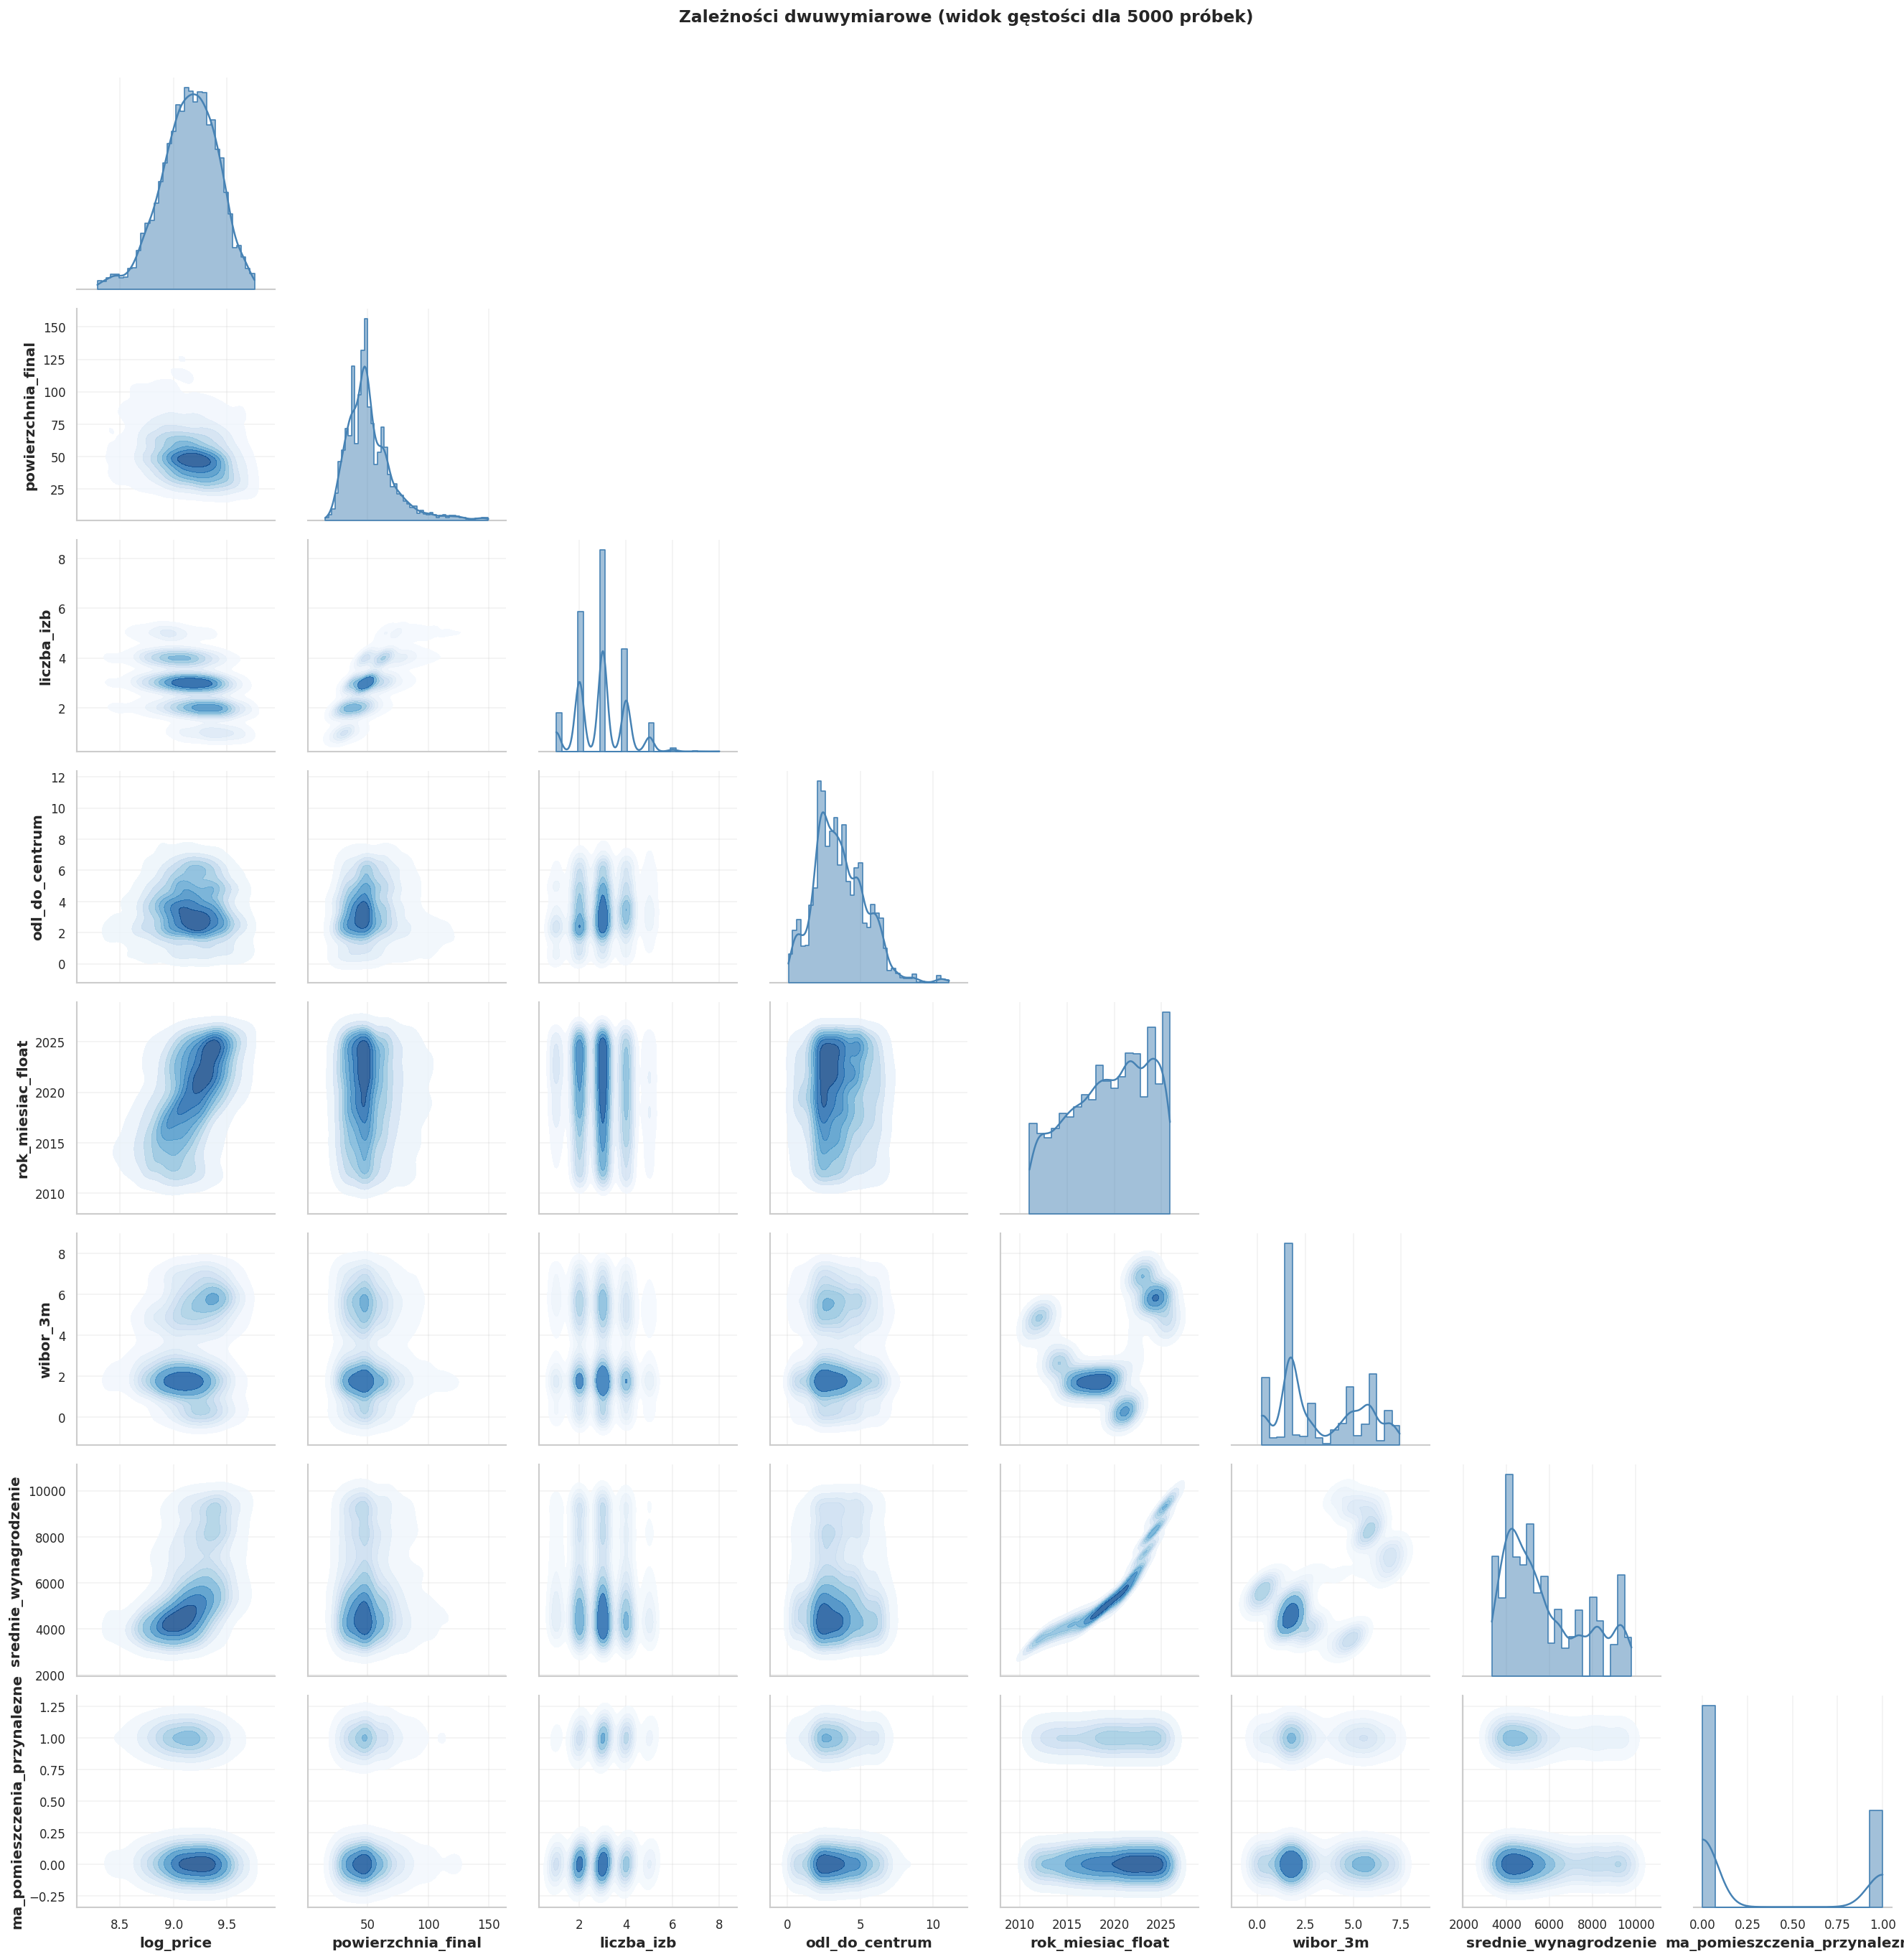

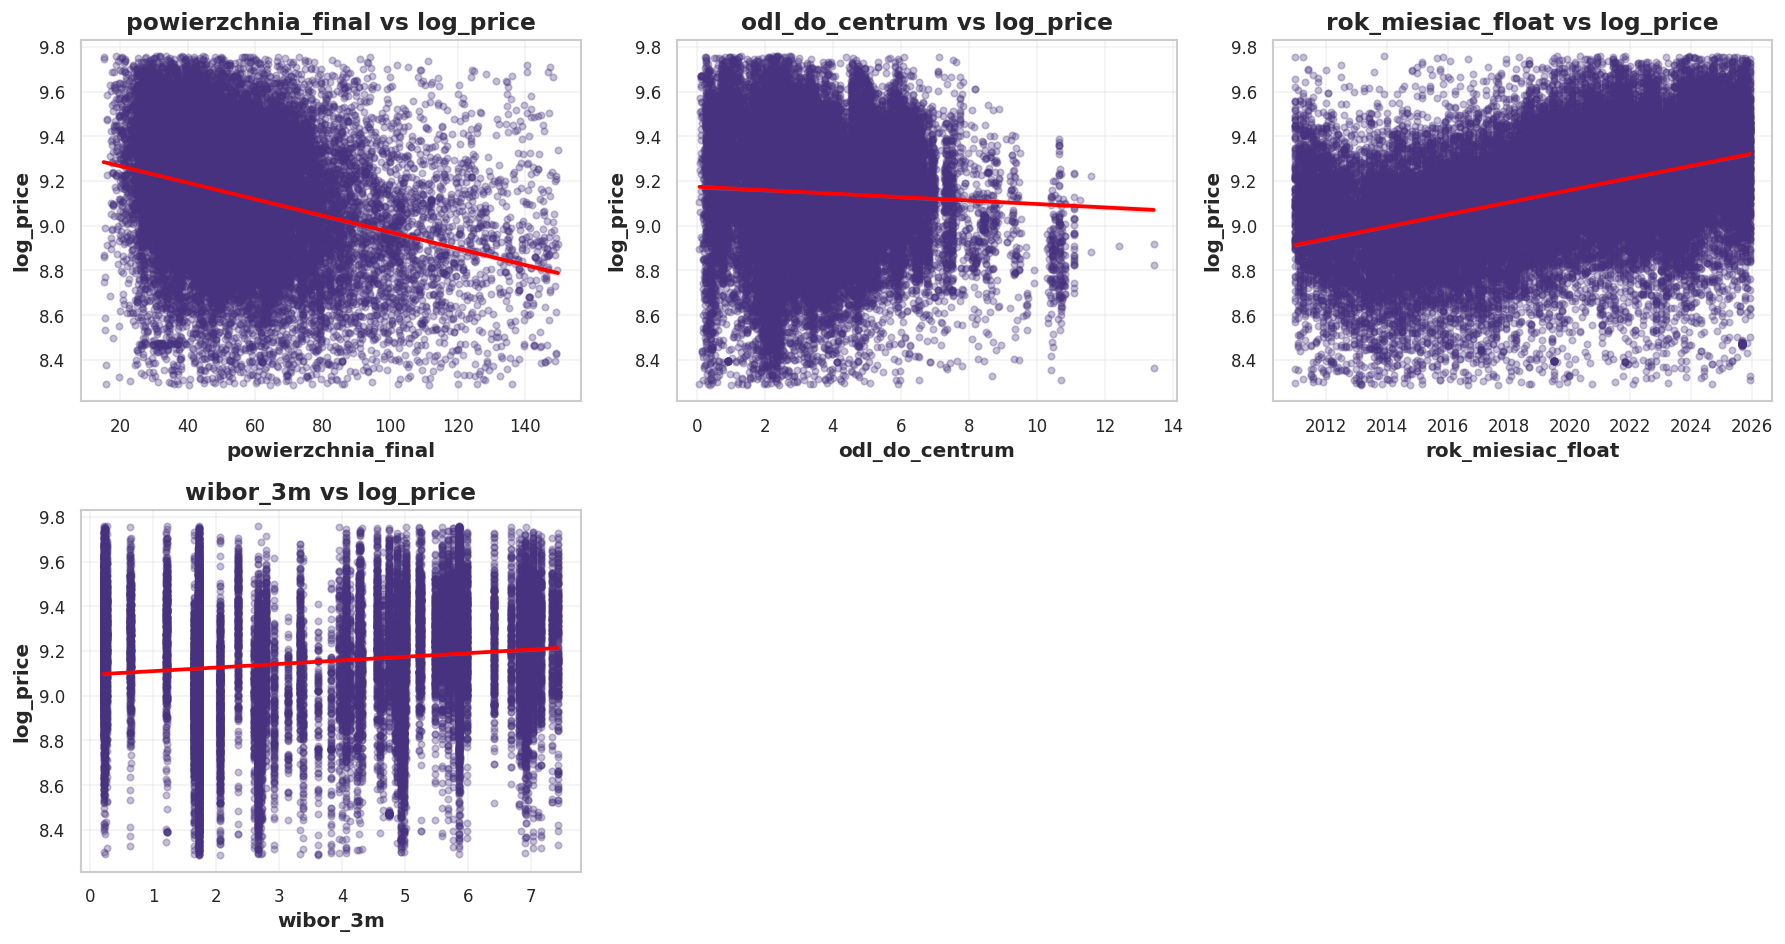

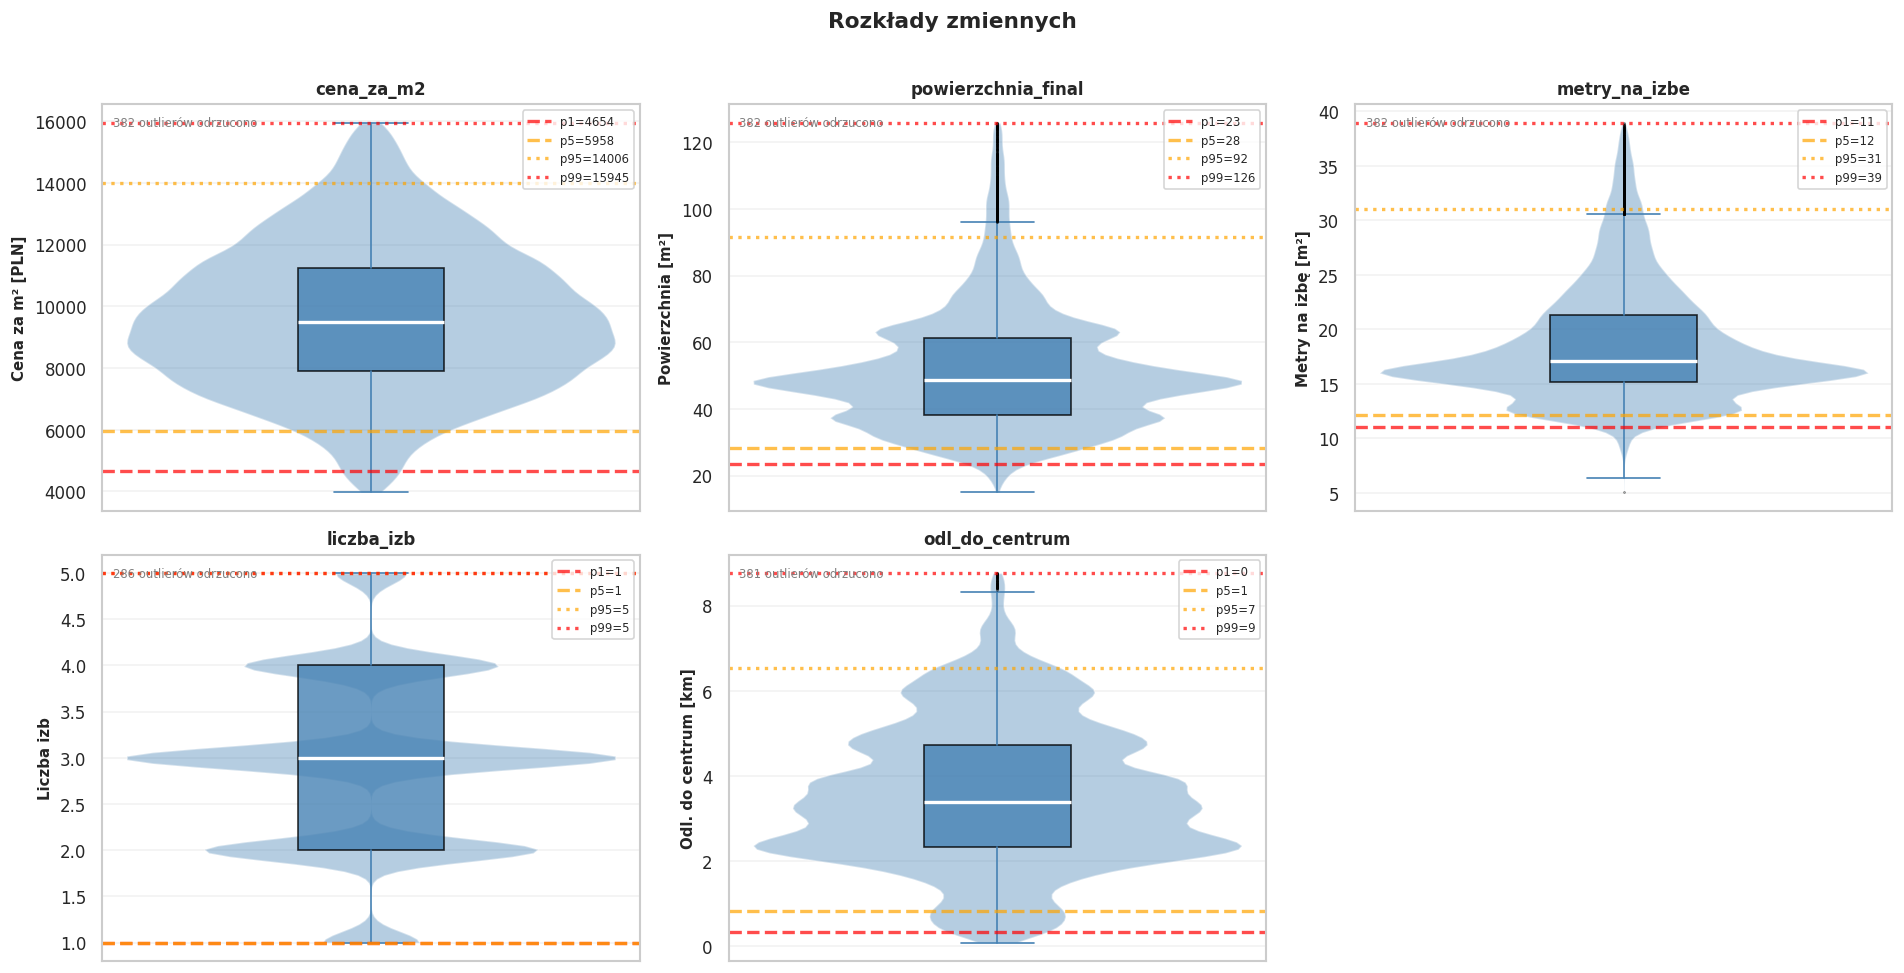

In [9]:
from src.clustering import (
    elbow_analysis,
    fit_property_clustering,
    fit_spatial_clustering,
    fit_temporal_clustering,
    profile_clusters,
)
from src.viz import (
    plot_bivariate_density,
    plot_distributions,
    plot_hexbin,
    plot_kmeans_silhouette_analysis,
    plot_property_segments,
    plot_target_relationships,
    plot_temporal_segments,
    plot_clusters_on_map,
)

plots_dir = project_root / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)
artifacts_dir = plots_dir
artifacts_dir.mkdir(parents=True, exist_ok=True)

rel_features = [
    "log_price", "powierzchnia_final", "liczba_izb", "odl_do_centrum", "rok_miesiac_float",
    "wibor_3m", "srednie_wynagrodzenie", "ma_pomieszczenia_przynalezne",
]
plot_bivariate_density(
    df[rel_features].dropna(),
    rel_features,
    sample_n=5000,
    save_path=artifacts_dir / "kde_pairwise_density.png",
)

plot_target_relationships(
    df.sort_values("rok_miesiac_float").dropna(subset=["log_price", "powierzchnia_final", "odl_do_centrum", "wibor_3m"]),
    target_col="log_price",
    features=["powierzchnia_final", "odl_do_centrum", "rok_miesiac_float", "wibor_3m"],
    save_path=artifacts_dir / "target_relationships.png",
)

plot_distributions(
    df,
    cols={
        "cena_za_m2": "Cena za m² [PLN]",
        "powierzchnia_final": "Powierzchnia [m²]",
        "metry_na_izbe": "Metry na izbę [m²]",
        "liczba_izb": "Liczba izb",
        "odl_do_centrum": "Odl. do centrum [km]",
    },
    save_path=artifacts_dir / "feature_distributions.png",
)

### 8.1 Spatial Hexbin Pricing Density
Hexagonal binning visualizes spatial price clustering and density across Poznań.


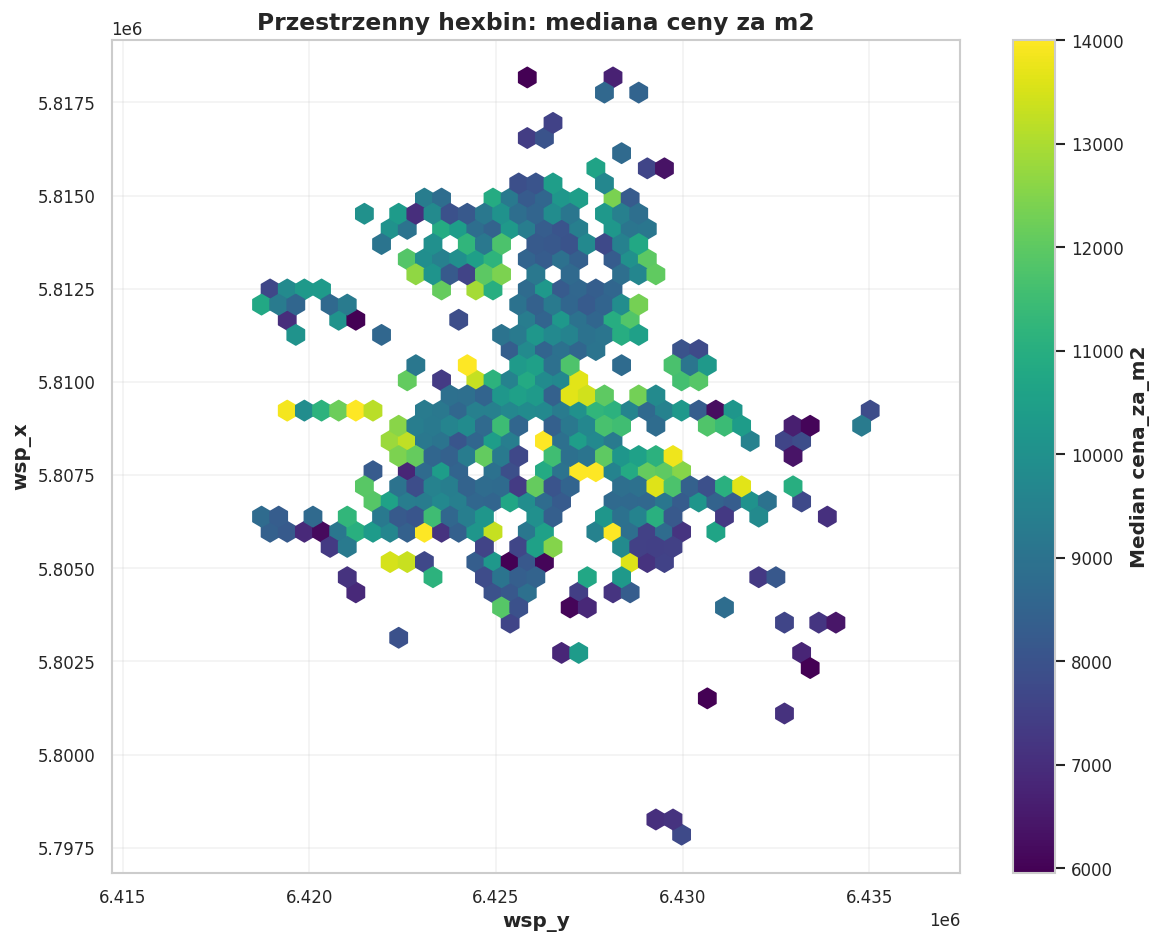

In [10]:
hex_df = df.dropna(subset=["wsp_x", "wsp_y", "cena_za_m2"]).copy()
plot_hexbin(hex_df, "wsp_y", "wsp_x", "cena_za_m2", save_path=artifacts_dir / "hexbin_price_map.png")

### 8.2 Spatial HDBSCAN Clustering
Density-based clustering partitions transactions into spatial submarkets while labeling sparse peripheral observations as noise (`cluster = -1`).


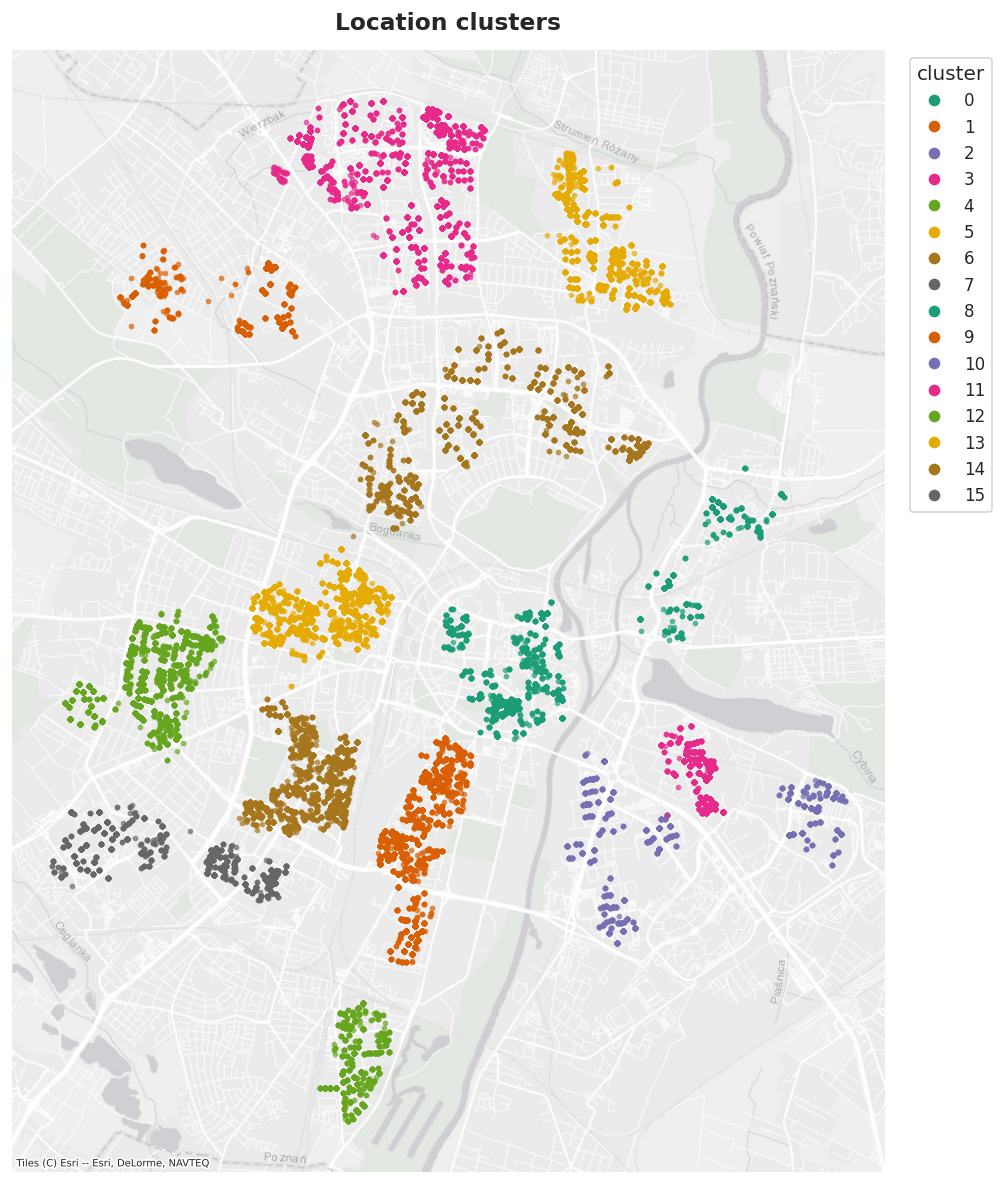

,avg_price_m2,median_price_m2,std_price_m2,n_properties,avg_dist_km,min_dist_km,max_dist_km,center_x,center_y
cluster,,,,,,,,,
11,11956.17,11911.37,1814.44,946,2.52,2.00,2.97,5807482.55,6429534.77
1,11030.74,11061.55,2080.92,743,5.43,4.58,6.44,5812994.17,6424175.10
0,10202.79,10497.11,2490.79,734,2.95,1.72,3.88,5810127.47,6429752.68
8,10162.03,10025.20,3043.82,1728,0.54,0.08,1.07,5808630.57,6427449.29
5,10017.53,9875.77,1900.54,2221,5.09,4.44,6.08,5813484.24,6428535.71


In [11]:
df_geo = df.dropna(subset=["wsp_x", "wsp_y"]).copy()
spatial_labels, _, _ = fit_spatial_clustering(df_geo[["wsp_x", "wsp_y"]], min_cluster_size=500)
df_geo["cluster"] = spatial_labels
plot_clusters_on_map(
    df_geo.query("cluster != -1"),
    x_col="wsp_y",
    y_col="wsp_x",
    cluster_col="cluster",
    save_path=artifacts_dir / "spatial_clusters.png",
)
spatial_profile = profile_clusters(df_geo, cluster_col="cluster")
spatial_profile.head()

### 8.3 Hedonic Property Typology Segmentation (K-Means)
Elbow and Silhouette analysis determine optimal cluster count $k=4$, segmenting apartments by size, floor, and central proximity.


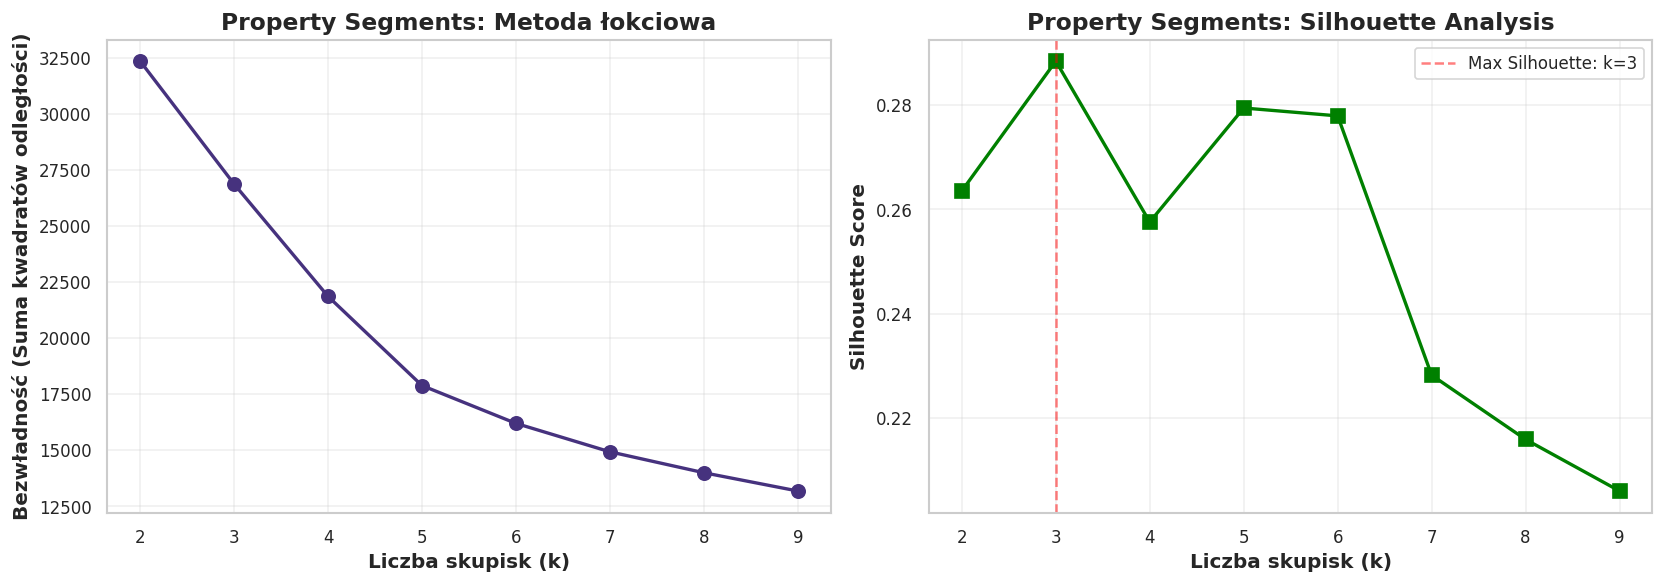

Optimal number of Property physical clusters (Silhouette): 3. Using 3 for clustering.


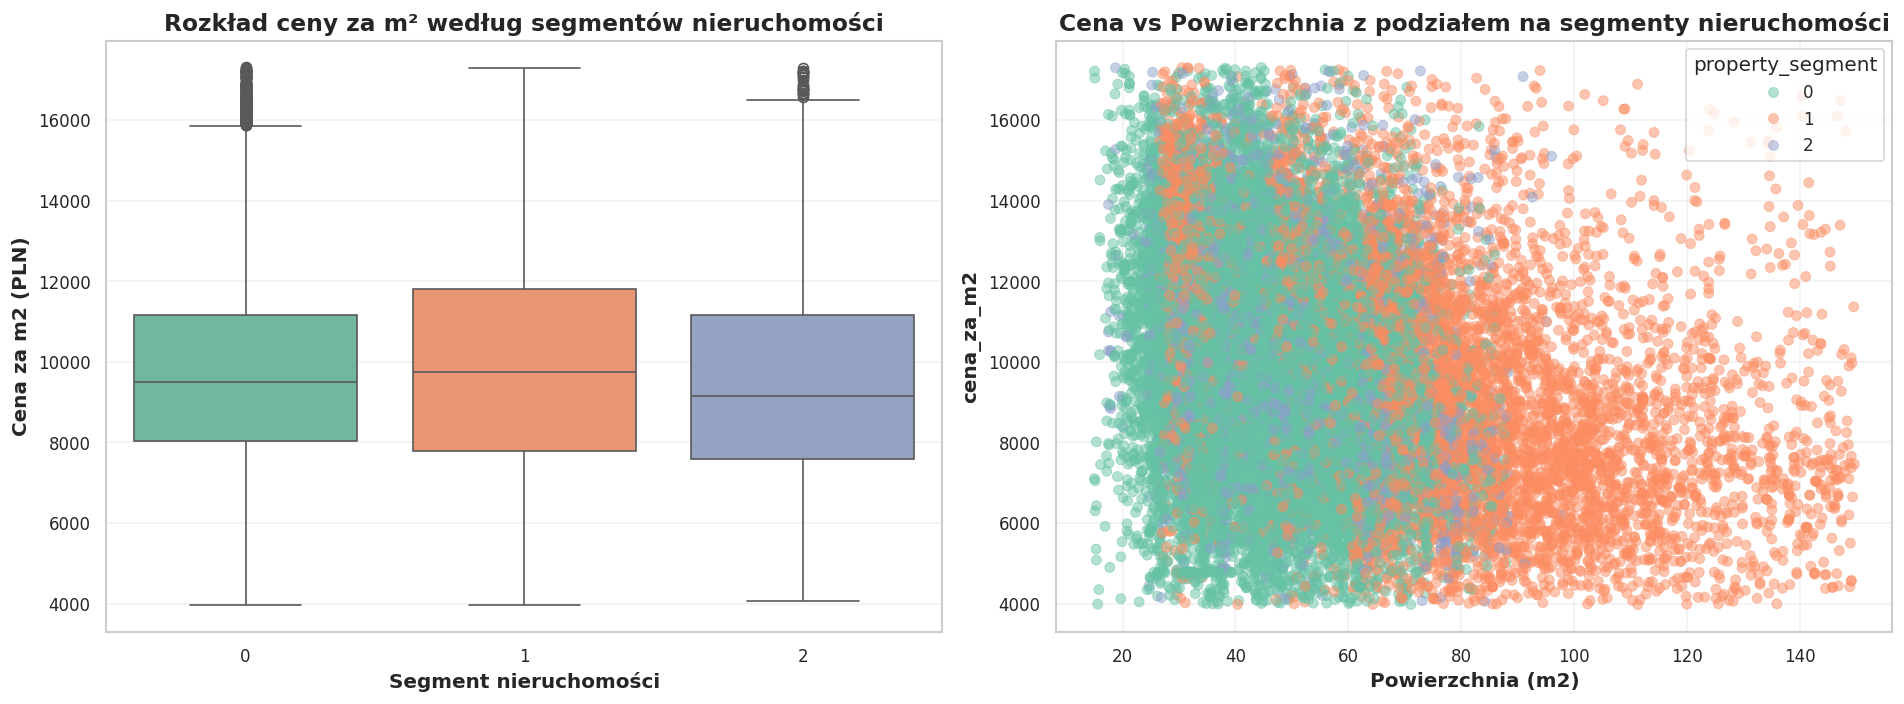

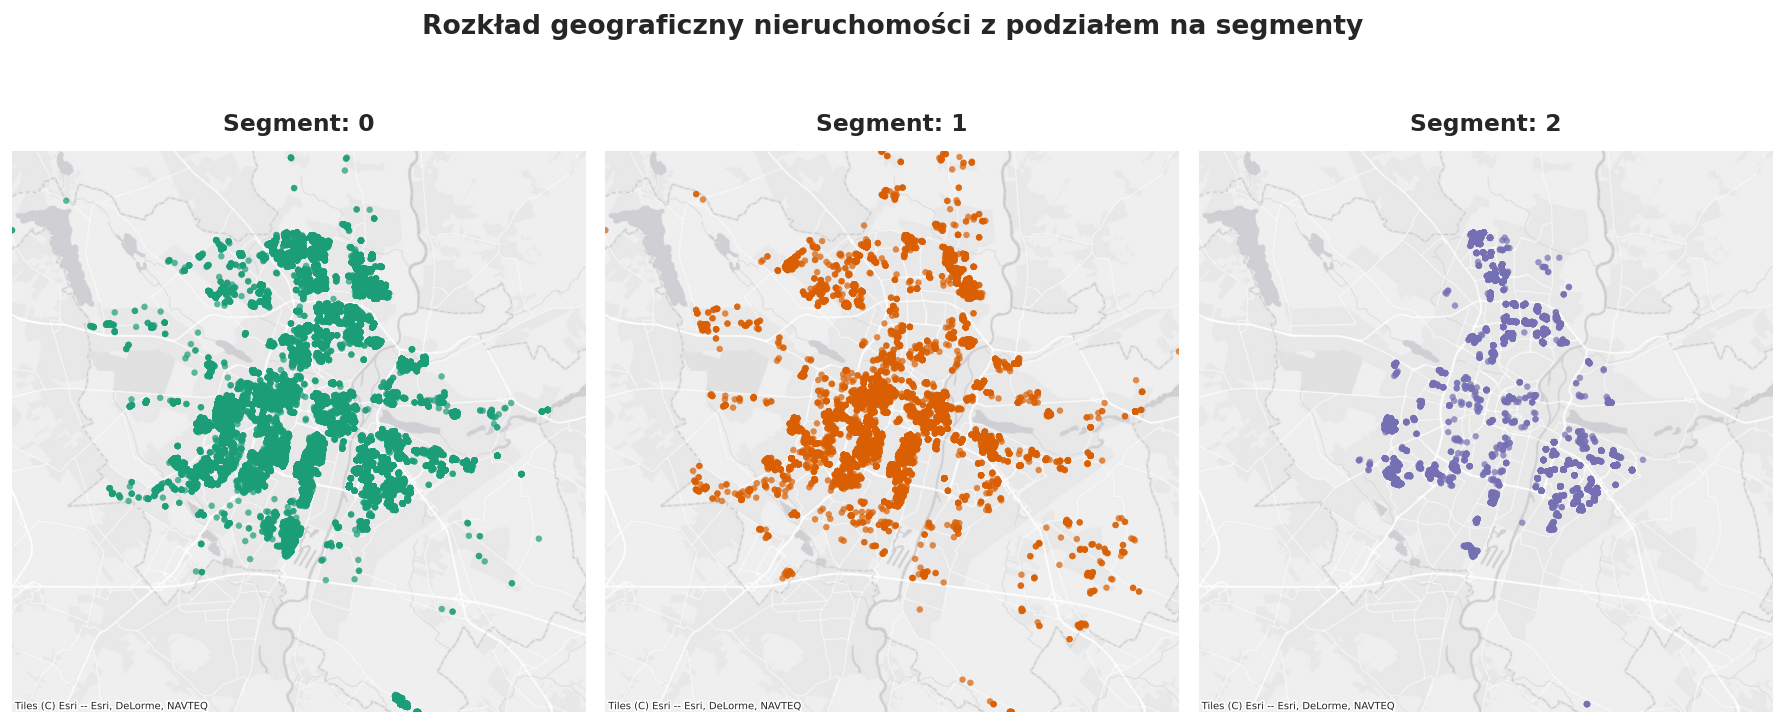

In [12]:
features_prop = [
    "powierzchnia_final",
    "metry_na_izbe",
    "odl_do_centrum",
    "nr_kondygnacji",
]

df_elbow = elbow_analysis(
    df[features_prop].sample(min(10000, len(df)), random_state=42),
    k_range=range(2, 10),
)
plot_kmeans_silhouette_analysis(df_elbow, title_prefix="Property Segments", save_path=artifacts_dir / "property_segmentation_elbow.png")

optimal_k_prop = df_elbow["silhouette"].idxmax()
print(f"Optimal number of Property physical clusters (Silhouette): {optimal_k_prop}. Using {optimal_k_prop} for clustering.")

prop_labels, _, _ = fit_property_clustering(df, n_clusters=optimal_k_prop, features=features_prop)
df["property_segment"] = df.index.map(dict(zip(prop_labels.index, prop_labels.values)))

property_profile = profile_clusters(
    df,
    cluster_col="property_segment",
    extra_cols=["rok"],
    feature_cols=features_prop,
)
property_profile.head()

plot_property_segments(df, cluster_col="property_segment", save_path=artifacts_dir / "cluster_property_segments.png")

### 8.4 Macroeconomic Market Regimes (K-Means)
Clustering across `rok_miesiac_float`, `wibor_3m`, and `srednie_wynagrodzenie` partitions transactions into three distinct monetary regimes: the pre-pandemic stable regime, the low-rate stimulus era, and the post-2022 inflation shock.


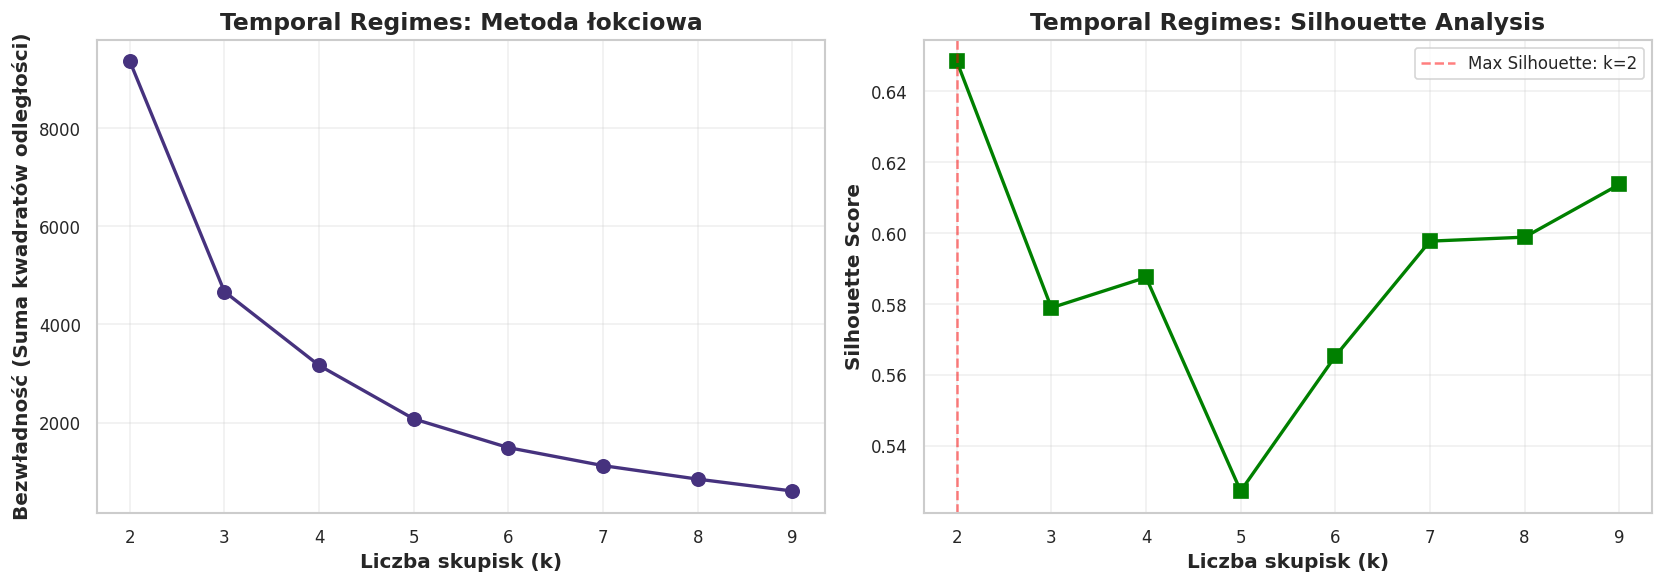

Optimal number of Market Regimes (Silhouette): 2. Applying 2.


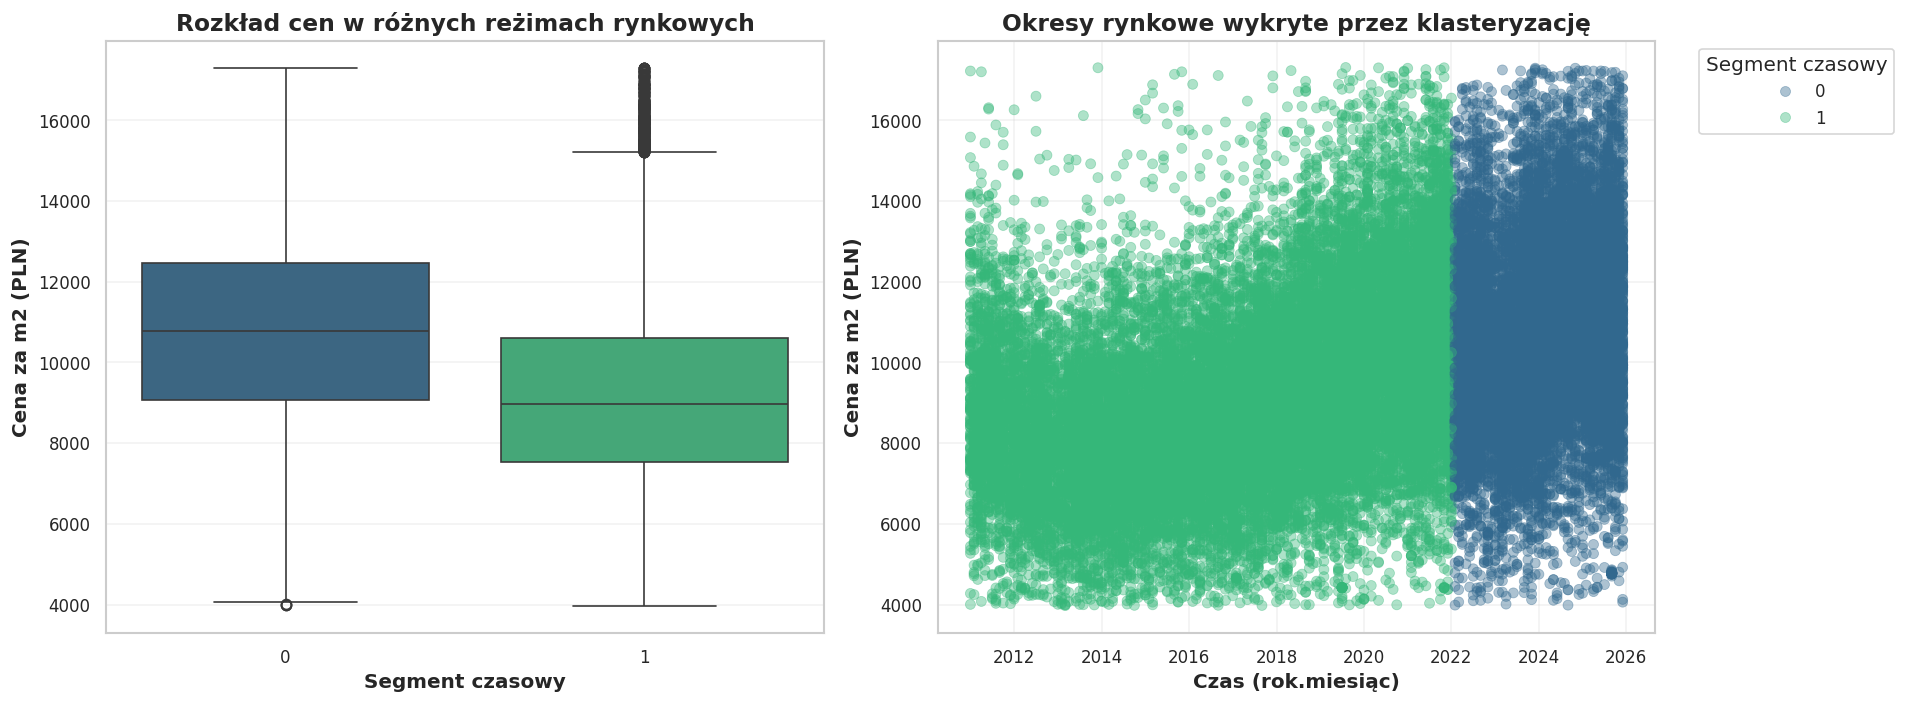

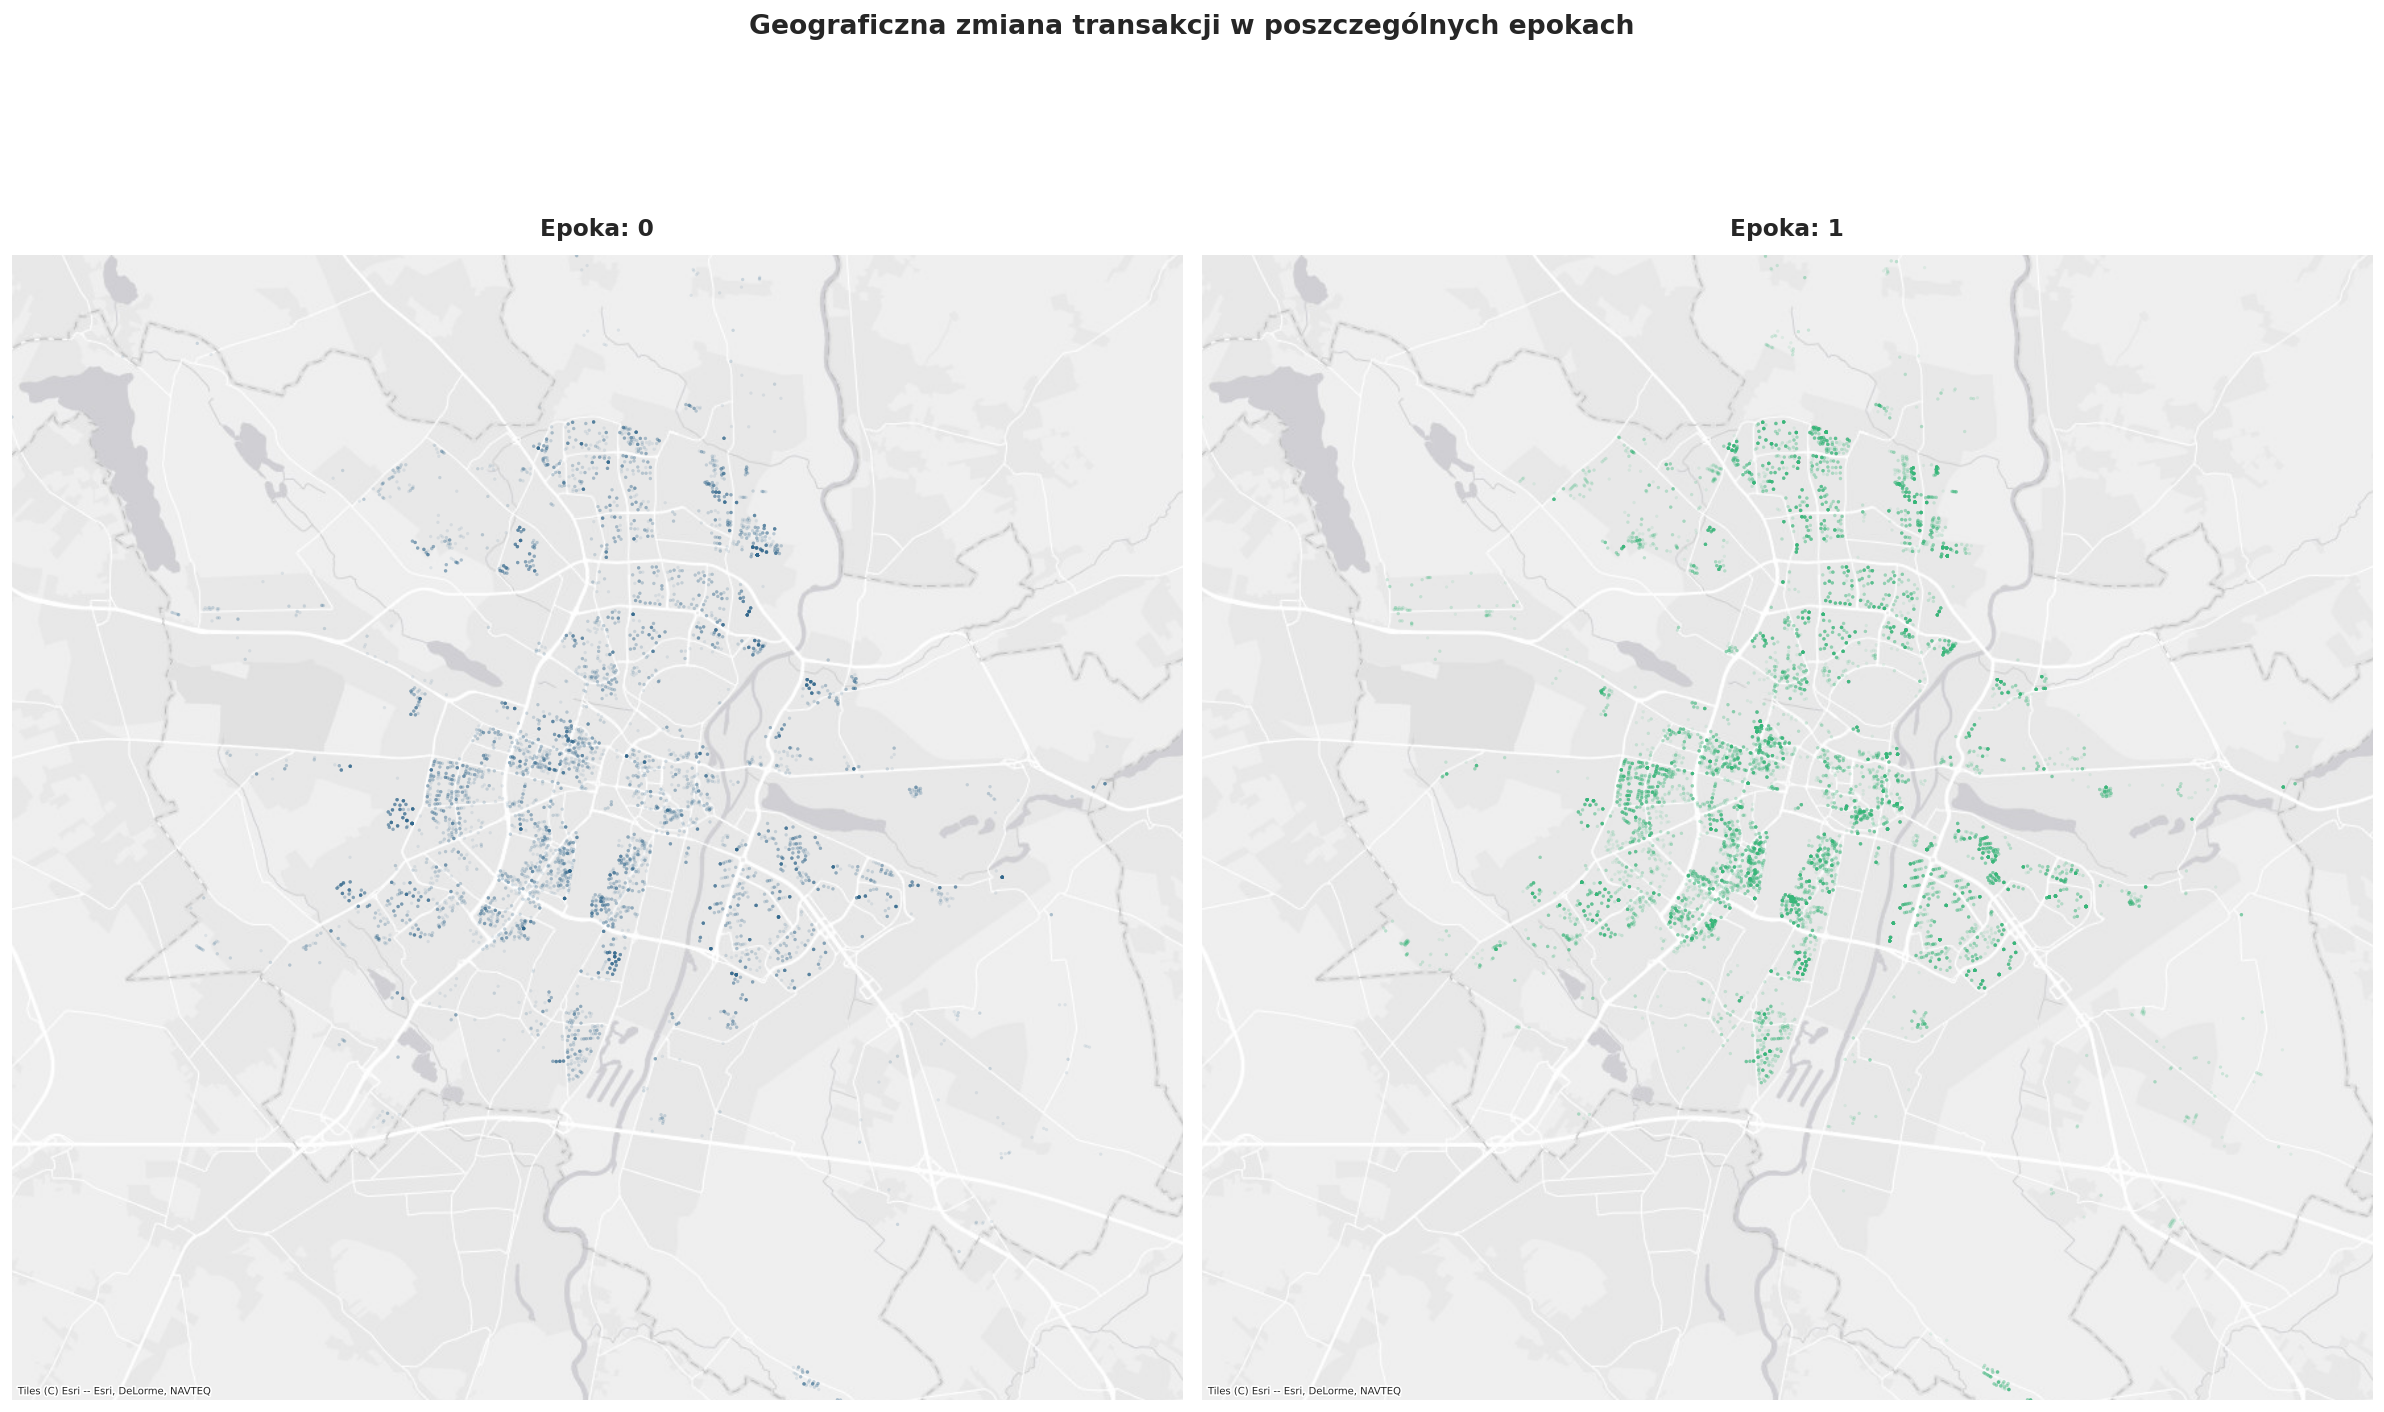

In [13]:
features_temp = ["rok_miesiac_float", "wibor_3m", "srednie_wynagrodzenie"]
df_elbow_temp = elbow_analysis(
    df[features_temp].sample(min(10000, len(df)), random_state=42),
    k_range=range(2, 10),
)
plot_kmeans_silhouette_analysis(df_elbow_temp, title_prefix="Temporal Regimes", save_path=artifacts_dir / "temporal_regime_elbow.png")

optimal_k_temp = df_elbow_temp["silhouette"].idxmax()
print(f"Optimal number of Market Regimes (Silhouette): {optimal_k_temp}. Applying {optimal_k_temp}.")

temp_labels, _, _ = fit_temporal_clustering(df, n_clusters=optimal_k_temp)
df["temporal_segment"] = df.index.map(dict(zip(temp_labels.index, temp_labels.values)))

temporal_profile = profile_clusters(
    df,
    cluster_col="temporal_segment",
    extra_cols=["rok", "cena_za_m2"],
)
temporal_profile.head()

plot_temporal_segments(df, cluster_col="temporal_segment", save_path=artifacts_dir / "temporal_segments.png")